In [1]:
import pandas as pd
import numpy as np
import seaborn as sn
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df = pd.read_csv('Placement_Data_Full_Class.csv')
df.head()

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,NaN
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sl_no           215 non-null    int64  
 1   gender          215 non-null    object 
 2   ssc_p           215 non-null    float64
 3   ssc_b           215 non-null    object 
 4   hsc_p           215 non-null    float64
 5   hsc_b           215 non-null    object 
 6   hsc_s           215 non-null    object 
 7   degree_p        215 non-null    float64
 8   degree_t        215 non-null    object 
 9   workex          215 non-null    object 
 10  etest_p         215 non-null    float64
 11  specialisation  215 non-null    object 
 12  mba_p           215 non-null    float64
 13  status          215 non-null    object 
 14  salary          148 non-null    float64
dtypes: float64(6), int64(1), object(8)
memory usage: 25.3+ KB


In [4]:
# seperating the categorical and numerical columns

catvars = list(df.select_dtypes(include=['object']).columns)

numvars = list(df.select_dtypes(include=['int32','int64','float32','float64']).columns)


print(catvars,numvars)

['gender', 'ssc_b', 'hsc_b', 'hsc_s', 'degree_t', 'workex', 'specialisation', 'status'] ['sl_no', 'ssc_p', 'hsc_p', 'degree_p', 'etest_p', 'mba_p', 'salary']


In [5]:
df.isnull().sum()

sl_no              0
gender             0
ssc_p              0
ssc_b              0
hsc_p              0
hsc_b              0
hsc_s              0
degree_p           0
degree_t           0
workex             0
etest_p            0
specialisation     0
mba_p              0
status             0
salary            67
dtype: int64

### Handling Null values

In [6]:
df.shape

(215, 15)

In [7]:
def plotdistplot(col):
    
    plt.figure(figsize=(15,7))
    sn.distplot(df['salary'],kde=True,hist=False,label='Actual Salary',color='orange')
    sn.distplot(df[col],kde=True,hist=False,label=col,color='black')
    

In [8]:
mostfreq = list(dict(df['salary'].value_counts()).items())[0]
mostfreq

(300000.0, 22)

In [9]:
df['salary'].mode()[0]

300000.0

In [10]:
df['salary_mean'] = df['salary'].fillna(df['salary'].mean())
df['salary_median'] = df['salary'].fillna(df['salary'].median())
df['salary_mode'] = df['salary'].fillna(df['salary'].mode()[0])
df.head()

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary,salary_mean,salary_median,salary_mode
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0,270000.000000,270000.0,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0,200000.000000,200000.0,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0,250000.000000,250000.0,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,NaN,288655.405405,265000.0,300000.0
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0,425000.000000,425000.0,425000.0


C:\Users\dell\AppData\Local\Temp\ipykernel_3040\3456693921.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sn.distplot(df['salary'],kde=True,hist=False,label='Actual Salary',color='orange')
C:\Users\dell\AppData\Local\Temp\ipykernel_3040\3456693921.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

 

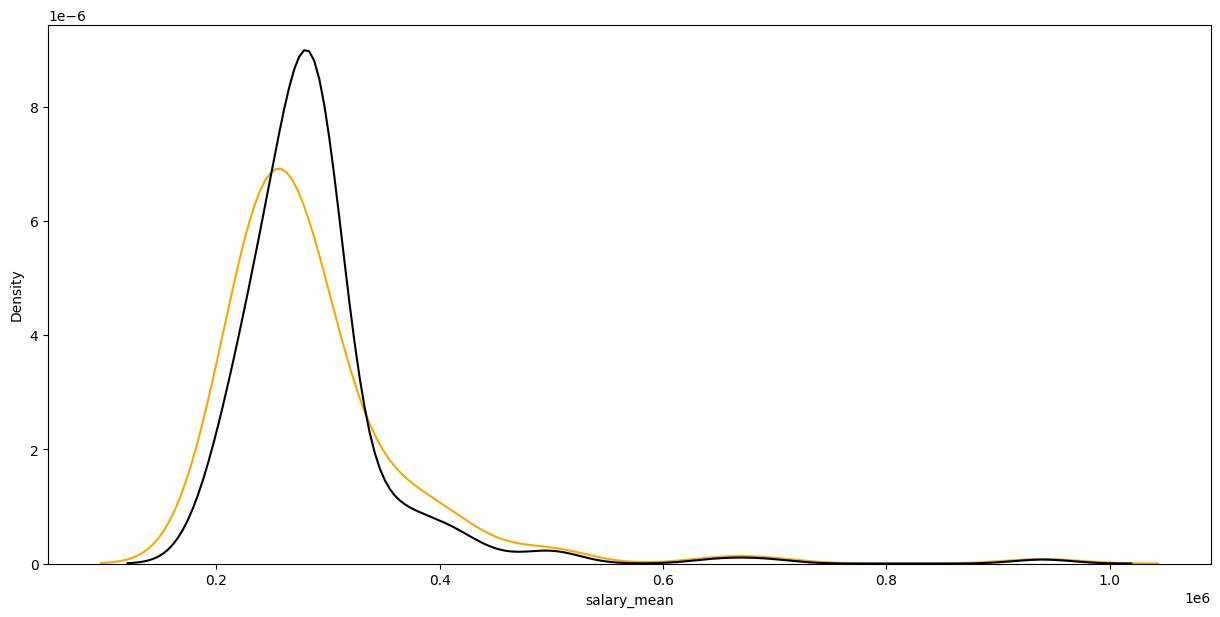

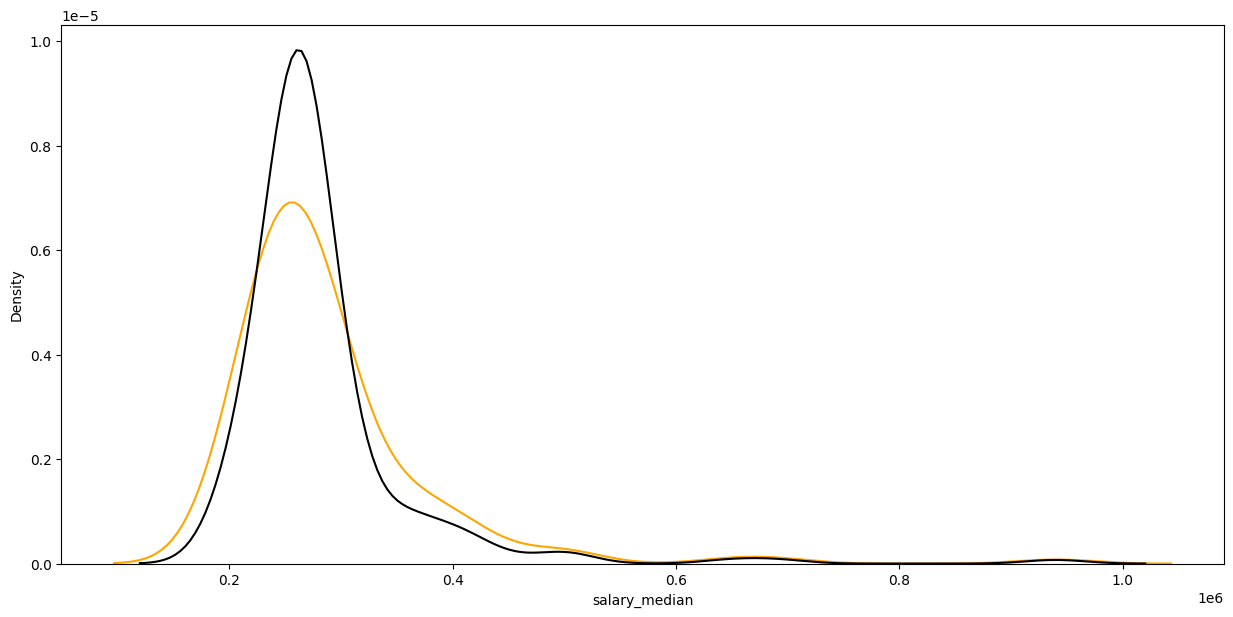

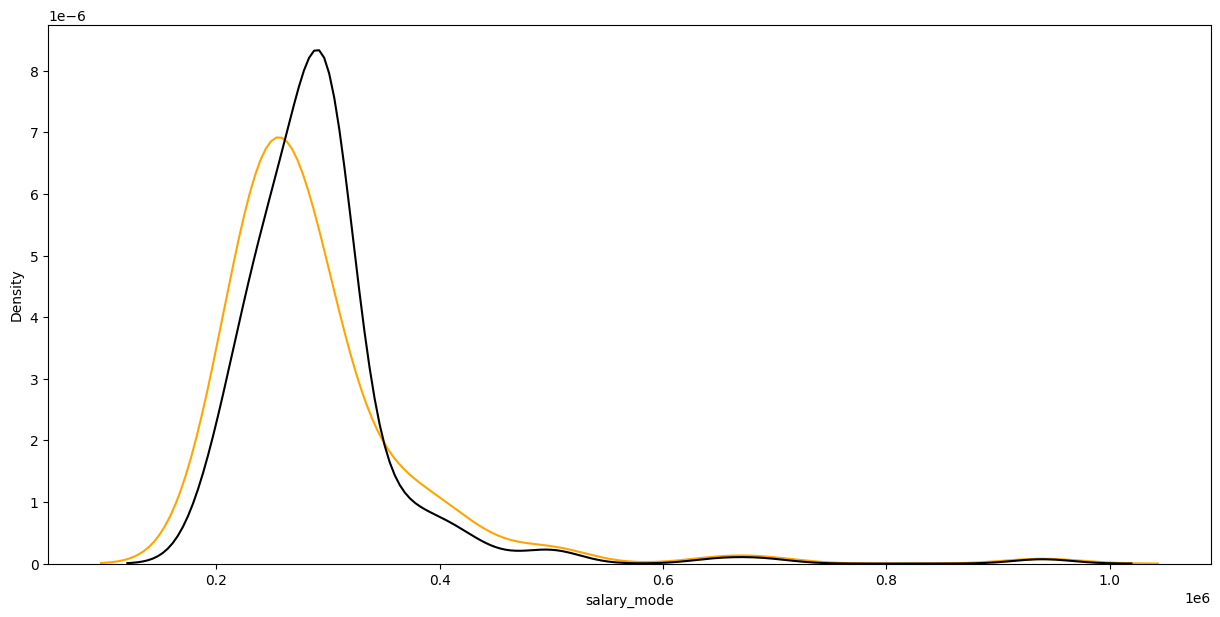

In [11]:
sallist = ['salary_mean','salary_median','salary_mode']
for sal in sallist:
    plotdistplot(sal)

In [12]:
# filling the salary with mean

df['salary'] = df['salary'].fillna(df['salary'].mean())
df.head()

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary,salary_mean,salary_median,salary_mode
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.000000,270000.000000,270000.0,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.000000,200000.000000,200000.0,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.000000,250000.000000,250000.0,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,288655.405405,288655.405405,265000.0,300000.0
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.000000,425000.000000,425000.0,425000.0


In [13]:
df = df.drop(columns=['salary_mean', 'salary_median', 'salary_mode'],axis=1)
df.isnull().sum()

sl_no             0
gender            0
ssc_p             0
ssc_b             0
hsc_p             0
hsc_b             0
hsc_s             0
degree_p          0
degree_t          0
workex            0
etest_p           0
specialisation    0
mba_p             0
status            0
salary            0
dtype: int64

## EDA

C:\Users\dell\AppData\Local\Temp\ipykernel_3040\4013246056.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sn.countplot(df['status'],palette='plasma')


<Axes: xlabel='count', ylabel='status'>

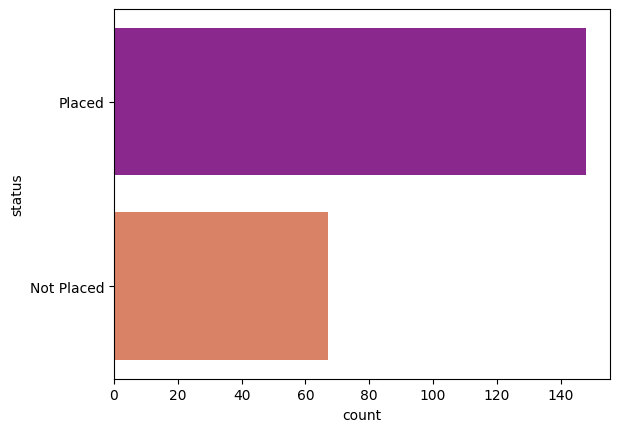

In [14]:
sn.countplot(df['status'],palette='plasma')

Count Plot for feature gender is shown ↓


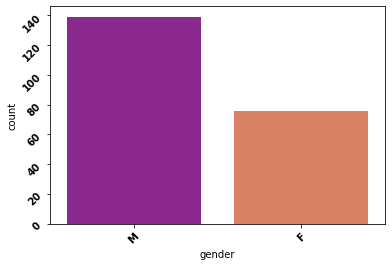

Count Plot for feature ssc_b is shown ↓


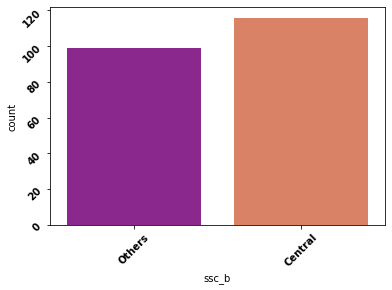

Count Plot for feature hsc_b is shown ↓


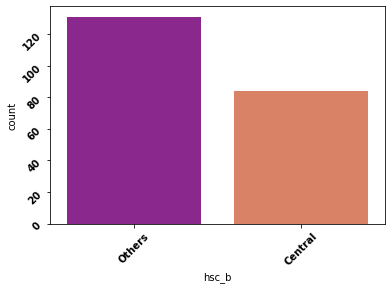

Count Plot for feature hsc_s is shown ↓


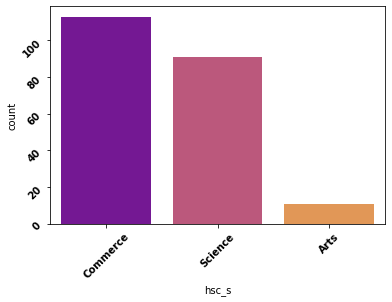

Count Plot for feature degree_t is shown ↓


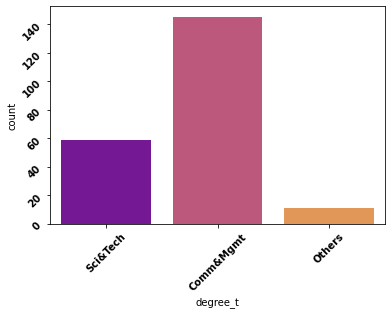

Count Plot for feature workex is shown ↓


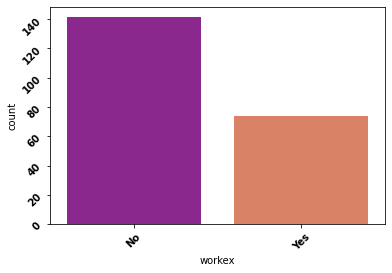

Count Plot for feature specialisation is shown ↓


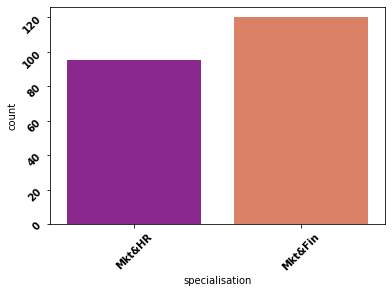

Count Plot for feature status is shown ↓


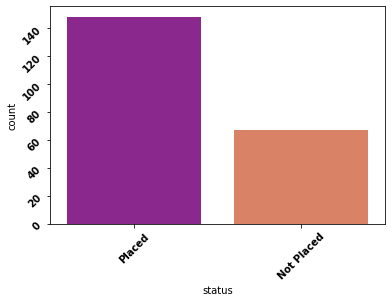

In [15]:
def valuecount(col):
    
    return dict(df[col].value_counts())

def getcountplot(col):
    
    sn.countplot(df[col],palette='plasma')
    plt.xticks(rotation = '45',fontweight = 'bold',fontsize = '10')
    plt.yticks(rotation = '45',fontweight = 'bold',fontsize = '10')
    plt.show()
    

for col in catvars:
    print(f'Count Plot for feature {col} is shown ↓')
    getcountplot(col)
    print('='*75)

In [6]:

import pandas as pd

df = pd.read_csv(r'Placement_Data_Full_Class.csv')

catvars = [col for col in df.columns if df[col].dtype == 'object']

def valuecount(col_name):
    """Return a dict with the frequency of each unique value in *col_name*."""
    return df[col_name].value_counts().to_dict()

getfinaldict = {}
for col in catvars:
    getfinaldict[col] = valuecount(col)
getfinaldict


{'gender': {'M': 139, 'F': 76},
 'ssc_b': {'Central': 116, 'Others': 99},
 'hsc_b': {'Others': 131, 'Central': 84},
 'hsc_s': {'Commerce': 113, 'Science': 91, 'Arts': 11},
 'degree_t': {'Comm&Mgmt': 145, 'Sci&Tech': 59, 'Others': 11},
 'workex': {'No': 141, 'Yes': 74},
 'specialisation': {'Mkt&Fin': 120, 'Mkt&HR': 95},
 'status': {'Placed': 148, 'Not Placed': 67}}

In [7]:
# top science students placed

df[(df['degree_t']=='Sci&Tech')&(df['status']=='Placed')].sort_values(by = 'salary',ascending = False).reset_index().head(5)
    

,index,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,150,151,M,71.00,Central,58.66,Central,Science,58.00,Sci&Tech,Yes,56.0,Mkt&Fin,61.30,Placed,690000.0
1,77,78,M,64.00,Others,80.00,Others,Science,65.00,Sci&Tech,Yes,69.0,Mkt&Fin,57.65,Placed,500000.0
2,163,164,M,63.00,Others,67.00,Others,Science,64.00,Sci&Tech,No,75.0,Mkt&Fin,66.46,Placed,500000.0
3,174,175,M,73.24,Others,50.83,Others,Science,64.27,Sci&Tech,Yes,64.0,Mkt&Fin,66.23,Placed,500000.0
4,53,54,M,80.00,Others,70.00,Others,Science,72.00,Sci&Tech,No,87.0,Mkt&HR,71.04,Placed,450000.0


In [8]:
# top Comm&Mgt students placed

df[(df['degree_t']=='Comm&Mgmt')&(df['status']=='Placed')].sort_values(by = 'salary',ascending = False).reset_index().head(5)
 

,index,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,119,120,M,60.8,Central,68.4,Central,Commerce,64.6,Comm&Mgmt,Yes,82.66,Mkt&Fin,64.34,Placed,940000.0
1,177,178,F,73.0,Central,97.0,Others,Commerce,79.0,Comm&Mgmt,Yes,89.00,Mkt&Fin,70.81,Placed,650000.0
2,4,5,M,85.8,Central,73.6,Central,Commerce,73.3,Comm&Mgmt,No,96.80,Mkt&Fin,55.50,Placed,425000.0
3,95,96,M,73.0,Central,78.0,Others,Commerce,65.0,Comm&Mgmt,Yes,95.46,Mkt&Fin,62.16,Placed,420000.0
4,210,211,M,80.6,Others,82.0,Others,Commerce,77.6,Comm&Mgmt,No,91.00,Mkt&Fin,74.49,Placed,400000.0


In [9]:
# max and min salary
# observation : max salary : 9,40,000 and min salary : 2,00,000

df[(df['salary']==max(df['salary'])) | (df['salary']==min(df['salary']))]

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.50,Mkt&Fin,66.28,Placed,200000.0
15,16,F,65.00,Central,75.00,Central,Commerce,69.00,Comm&Mgmt,Yes,72.00,Mkt&Fin,64.66,Placed,200000.0
44,45,F,77.00,Others,73.00,Others,Commerce,81.00,Comm&Mgmt,Yes,89.00,Mkt&Fin,69.70,Placed,200000.0
50,51,F,75.20,Central,73.20,Central,Science,68.40,Comm&Mgmt,No,65.00,Mkt&HR,62.98,Placed,200000.0
107,108,M,82.00,Others,90.00,Others,Commerce,83.00,Comm&Mgmt,No,80.00,Mkt&HR,73.52,Placed,200000.0
119,120,M,60.80,Central,68.40,Central,Commerce,64.60,Comm&Mgmt,Yes,82.66,Mkt&Fin,64.34,Placed,940000.0
135,136,F,72.00,Central,56.00,Others,Science,69.00,Comm&Mgmt,No,55.60,Mkt&HR,65.63,Placed,200000.0


In [10]:
# students with salary more than avg salary science dept

df[(df['degree_t']=='Sci&Tech')&(df['salary']>df['salary'].mean())].sort_values(by = 'salary',ascending = False).reset_index()

,index,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,150,151,M,71.00,Central,58.66,Central,Science,58.00,Sci&Tech,Yes,56.00,Mkt&Fin,61.30,Placed,690000.0
1,174,175,M,73.24,Others,50.83,Others,Science,64.27,Sci&Tech,Yes,64.00,Mkt&Fin,66.23,Placed,500000.0
2,77,78,M,64.00,Others,80.00,Others,Science,65.00,Sci&Tech,Yes,69.00,Mkt&Fin,57.65,Placed,500000.0
3,163,164,M,63.00,Others,67.00,Others,Science,64.00,Sci&Tech,No,75.00,Mkt&Fin,66.46,Placed,500000.0
4,53,54,M,80.00,Others,70.00,Others,Science,72.00,Sci&Tech,No,87.00,Mkt&HR,71.04,Placed,450000.0
5,39,40,M,81.00,Others,68.00,Others,Science,64.00,Sci&Tech,No,93.00,Mkt&Fin,62.56,Placed,411000.0
6,145,146,M,89.40,Others,65.66,Others,Science,71.25,Sci&Tech,No,72.00,Mkt&HR,63.23,Placed,400000.0
7,128,129,M,80.40,Central,73.40,Central,Science,77.72,Sci&Tech,Yes,81.20,Mkt&HR,76.26,Placed,400000.0
8,22,23,F,69.80,Others,60.80,Others,Science,72.23,Sci&Tech,No,55.53,Mkt&HR,68.81,Placed,360000.0
9,24,25,M,76.50,Others,97.70,Others,Science,78.86,Sci&Tech,No,97.40,Mkt&Fin,74.01,Placed,360000.0


In [11]:
# students with salary more than avg salary Comm&Mgmt dept

df[(df['degree_t']=='Comm&Mgmt')&(df['salary']>df['salary'].mean())].sort_values(by = 'salary',ascending = False).reset_index()

,index,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,119,120,M,60.80,Central,68.40,Central,Commerce,64.60,Comm&Mgmt,Yes,82.66,Mkt&Fin,64.34,Placed,940000.0
1,177,178,F,73.00,Central,97.00,Others,Commerce,79.00,Comm&Mgmt,Yes,89.00,Mkt&Fin,70.81,Placed,650000.0
2,4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.80,Mkt&Fin,55.50,Placed,425000.0
3,95,96,M,73.00,Central,78.00,Others,Commerce,65.00,Comm&Mgmt,Yes,95.46,Mkt&Fin,62.16,Placed,420000.0
4,85,86,F,83.84,Others,89.83,Others,Commerce,77.20,Comm&Mgmt,Yes,78.74,Mkt&Fin,76.18,Placed,400000.0
5,210,211,M,80.60,Others,82.00,Others,Commerce,77.60,Comm&Mgmt,No,91.00,Mkt&Fin,74.49,Placed,400000.0
6,21,22,F,79.00,Others,76.00,Others,Commerce,85.00,Comm&Mgmt,No,95.00,Mkt&Fin,69.06,Placed,393000.0
7,101,102,M,63.00,Central,72.00,Central,Commerce,68.00,Comm&Mgmt,No,78.00,Mkt&HR,60.44,Placed,380000.0
8,104,105,M,69.00,Central,63.00,Others,Science,65.00,Comm&Mgmt,Yes,55.00,Mkt&HR,58.23,Placed,360000.0
9,57,58,M,68.00,Central,76.00,Central,Commerce,74.00,Comm&Mgmt,No,80.00,Mkt&Fin,63.59,Placed,360000.0


<Axes: xlabel='degree_t'>

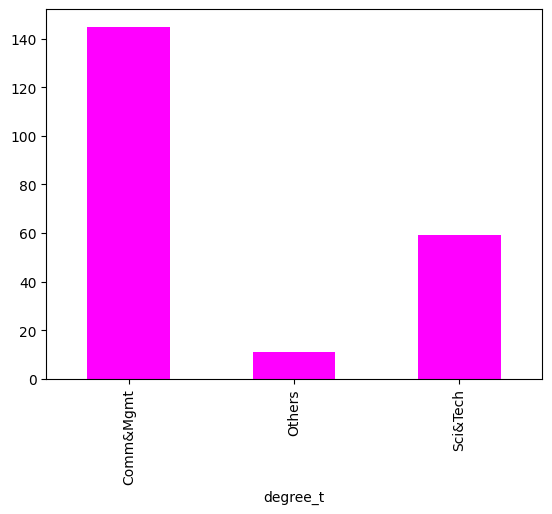

In [12]:
# maximum students placed are from comm&mgt

df.groupby(['degree_t'])['status'].count().plot(kind = 'bar',color = 'magenta')

<Axes: xlabel='specialisation'>

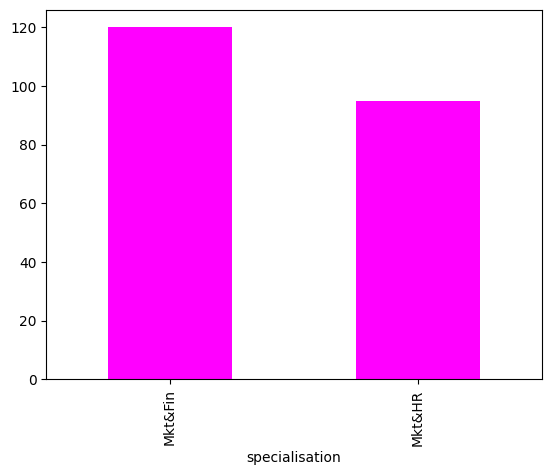

In [13]:
# Marketing and Finance specialisation are placed more

df.groupby(['specialisation'])['status'].count().plot(kind = 'bar',color = 'magenta')

<Axes: ylabel='status'>

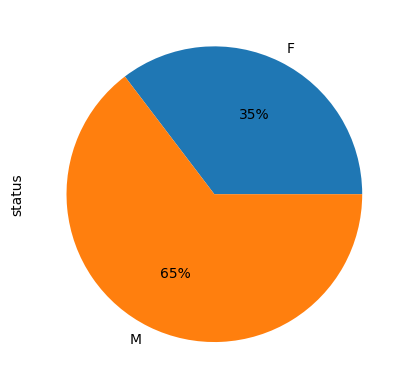

In [14]:
# females placed 35% and males 65%

df.groupby(['gender'])['status'].count().plot(kind = 'pie',autopct='%1.0f%%')

In [17]:
print(df['salary'].dtype)           # should show: int64
print(df['salary'].head())


float64
0    270000.0
1    200000.0
2    250000.0
3         NaN
4    425000.0
Name: salary, dtype: float64


<Axes: ylabel='status'>

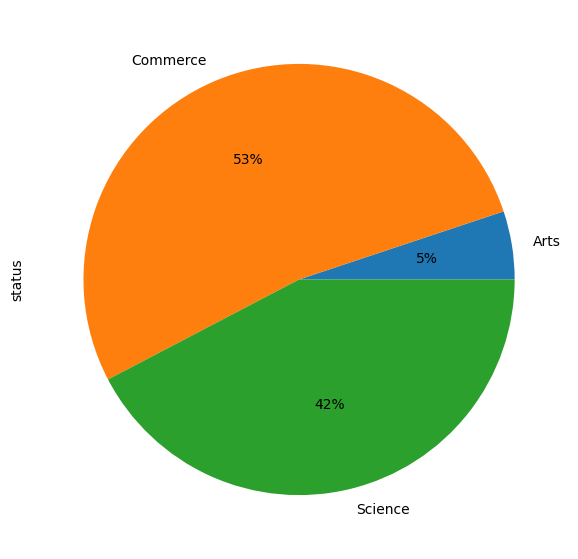

In [18]:
df.groupby(['hsc_s'])['status'].count().plot(kind = 'pie',autopct='%1.0f%%',figsize=(15,7))

In [19]:
df.head()

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,NaN
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0


In [20]:
getfinaldict

{'gender': {'M': 139, 'F': 76},
 'ssc_b': {'Central': 116, 'Others': 99},
 'hsc_b': {'Others': 131, 'Central': 84},
 'hsc_s': {'Commerce': 113, 'Science': 91, 'Arts': 11},
 'degree_t': {'Comm&Mgmt': 145, 'Sci&Tech': 59, 'Others': 11},
 'workex': {'No': 141, 'Yes': 74},
 'specialisation': {'Mkt&Fin': 120, 'Mkt&HR': 95},
 'status': {'Placed': 148, 'Not Placed': 67}}

In [21]:
len(getfinaldict['status']),len(getfinaldict['degree_t'])

(2, 3)

In [22]:
boolcols = [key for key,value in getfinaldict.items() if len(getfinaldict[key])==2]
tripcols = [key for key in list(getfinaldict.keys()) if key not in boolcols]

print(boolcols,tripcols)

['gender', 'ssc_b', 'hsc_b', 'workex', 'specialisation', 'status'] ['hsc_s', 'degree_t']


## Label Encoding process

In [23]:
def labelencode(le,col):
    
    df[col] = le.fit_transform(df[col])
    
    
getmappings = {}
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in list(getfinaldict.keys()):
    labelencode(le,col)
    getmappings[col] = dict(zip(le.classes_,le.transform(le.classes_)))
    

df.head()


,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,1,67.00,1,91.00,1,1,58.00,2,0,55.0,1,58.80,1,270000.0
1,2,1,79.33,0,78.33,1,2,77.48,2,1,86.5,0,66.28,1,200000.0
2,3,1,65.00,0,68.00,0,0,64.00,0,0,75.0,0,57.80,1,250000.0
3,4,1,56.00,0,52.00,0,2,52.00,2,0,66.0,1,59.43,0,NaN
4,5,1,85.80,0,73.60,0,1,73.30,0,0,96.8,0,55.50,1,425000.0


In [24]:
# this was the internal mapping structure followed by label encoder for mapping

getmappings

{'gender': {'F': 0, 'M': 1},
 'ssc_b': {'Central': 0, 'Others': 1},
 'hsc_b': {'Central': 0, 'Others': 1},
 'hsc_s': {'Arts': 0, 'Commerce': 1, 'Science': 2},
 'degree_t': {'Comm&Mgmt': 0, 'Others': 1, 'Sci&Tech': 2},
 'workex': {'No': 0, 'Yes': 1},
 'specialisation': {'Mkt&Fin': 0, 'Mkt&HR': 1},
 'status': {'Not Placed': 0, 'Placed': 1}}

In [25]:
# removing unwated columns

df = df.drop(['sl_no'],axis=1)
df.head(2)

,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,67.00,1,91.00,1,1,58.00,2,0,55.0,1,58.80,1,270000.0
1,1,79.33,0,78.33,1,2,77.48,2,1,86.5,0,66.28,1,200000.0


## Numerical Columns EDA

In [29]:

numeric_dtypes = ['int64', 'float64', 'Int64', 'Float64']

numvars = [col for col in df.columns if df[col].dtype in numeric_dtypes]

print("All numeric columns:", numvars)
print("numvars[1:]:", numvars[1:])

numeric_means = df[numvars].mean()
print("\nMean values for numeric columns:\n", numeric_means)


All numeric columns: ['ssc_p', 'hsc_p', 'degree_p', 'etest_p', 'mba_p', 'salary']
numvars[1:]: ['hsc_p', 'degree_p', 'etest_p', 'mba_p', 'salary']

Mean values for numeric columns:
 ssc_p           67.303395
hsc_p           66.333163
degree_p        66.370186
etest_p         72.100558
mba_p           62.278186
salary      288655.405405
dtype: float64


In [30]:
import scipy.stats as stats

def getplots(df,col):
    
    plt.figure(figsize=(15,7))
    plt.subplot(1,3,1)
    plt.hist(df[col],color='magenta')
    
    plt.subplot(1,3,2)
    stats.probplot(df[col],dist='norm',plot=plt)
    
    plt.subplot(1,3,3)
    sn.boxplot(df[col],color='magenta')
    
    plt.show()
    
    
for col in numvars[1:]:
    print(f'Distribution plots for col : {col} are shown ↓')
    getplots(df,col)
    print('='*10)

Distribution plots for col : hsc_p are shown ↓


NameError: name 'plt' is not defined

# Feature Selection

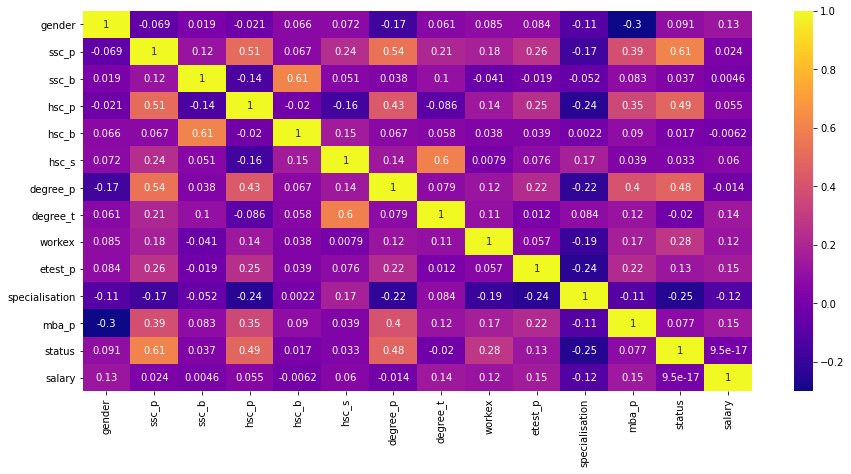

In [36]:
# checking for tightly correlated features

plt.figure(figsize=(15,7))
sn.heatmap(df.corr(),annot=True,cmap='plasma')

In [37]:
'''
We will drop the salary column as well
coz after getting the placement we will get to know the salary right!

'''


data = df.copy()
test = data['status']
train = data.drop(['status','salary'],axis = 1)
train.head(2)


,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p
0,1,67.00,1,91.00,1,1,58.00,2,0,55.0,1,58.80
1,1,79.33,0,78.33,1,2,77.48,2,1,86.5,0,66.28


In [38]:
## extratrees classifier

from sklearn.ensemble import ExtraTreesClassifier
ec = ExtraTreesClassifier()
ec.fit(train,test)

ExtraTreesClassifier()

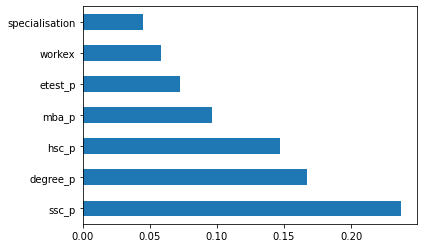

In [39]:
featbar = pd.Series(ec.feature_importances_,index=train.columns)
featbar.nlargest(7).plot(kind = 'barh')

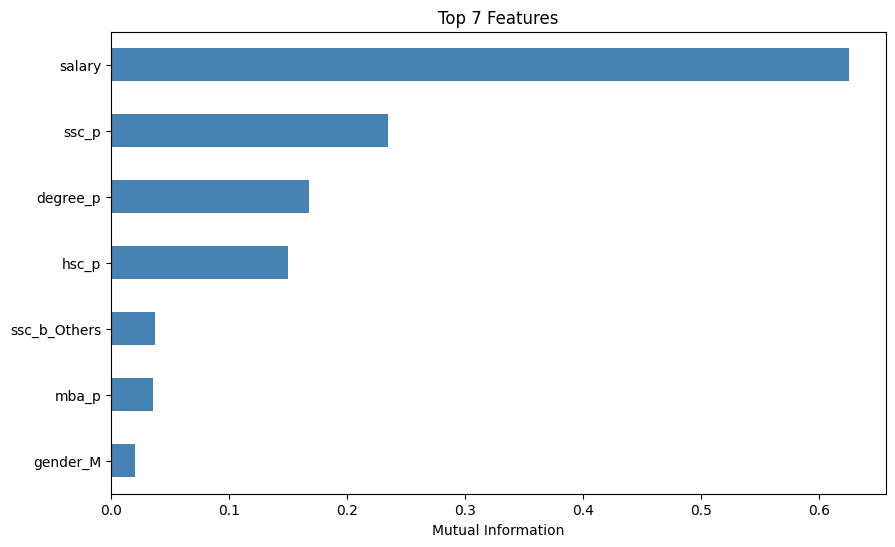

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split

df = pd.read_csv(r'Placement_Data_Full_Class.csv')
df['salary'] = pd.to_numeric(df['salary'], errors='coerce')
df = df.fillna(0)

y = LabelEncoder().fit_transform(df['status'])
X = pd.get_dummies(df.drop(columns=['sl_no', 'status']), drop_first=True)

X_train, _, y_train, _ = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

mi = pd.Series(mutual_info_classif(X_train, y_train, random_state=42), index=X_train.columns)
mi.nlargest(7).plot(kind='barh', figsize=(10, 6), color='steelblue')
plt.xlabel('Mutual Information')
plt.title('Top 7 Features')
plt.gca().invert_yaxis()
plt.show()


In [42]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif

df = pd.read_csv(r'Placement_Data_Full_Class.csv')
df['salary'] = pd.to_numeric(df['salary'], errors='coerce').fillna(0)

# ---------- top‑10 by frequency ----------
featbar = df['degree_p'].value_counts()
featcol  = featbar.nlargest(10).index.tolist()

# ---------- top‑10 by mutual information ----------
y = LabelEncoder().fit_transform(df['status'])
X = pd.get_dummies(df.drop(columns=['sl_no', 'status']), drop_first=True)
mi = pd.Series(mutual_info_classif(X, y, random_state=42), index=X.columns)
mutclasif = mi.nlargest(10).index.tolist()

# ---------- intersection ----------
commoncols = list(set(featcol) & set(mutclasif))
print(commoncols)


[]


In [43]:
# selecting the common cols and will do training on these cols!
# these cols were selected as a nlargest result of 2 feature selection techniques!

train = df[commoncols]
train.head()

""
0
1
2
3
4


In [44]:
'''
From the above DF we notice that gender,specialisation,degree_t,workex are the 
categorical columns and they make sense isn't it?,for any placement drive
students are first filtered on basis of their boards,sem scores which in this case are {mba_p,ssc_p,degree_p,hsc_p}
and then workexperience also matters a lot!,then specialisation as well,gender is also important
because now-a-days few companies focus on women empowerment,so yes,all the features make perfect sense!

'''
getmappings

{'gender': {'F': 0, 'M': 1},
 'ssc_b': {'Central': 0, 'Others': 1},
 'hsc_b': {'Central': 0, 'Others': 1},
 'hsc_s': {'Arts': 0, 'Commerce': 1, 'Science': 2},
 'degree_t': {'Comm&Mgmt': 0, 'Others': 1, 'Sci&Tech': 2},
 'workex': {'No': 0, 'Yes': 1},
 'specialisation': {'Mkt&Fin': 0, 'Mkt&HR': 1},
 'status': {'Not Placed': 0, 'Placed': 1}}

In [46]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv(r'Placement_Data_Full_Class.csv')
df['salary'] = pd.to_numeric(df['salary'], errors='coerce').fillna(0)

train = df[['gender','specialisation','degree_t','workex',
            'ssc_p','hsc_p','degree_p','mba_p']]

train.columns = ['Gender','Specialisation','Techinal Degree',
                 'Work Experience','SSC_p','High School_p',
                 'Degree_p','MBA_p']

train.head()


,Gender,Specialisation,Techinal Degree,Work Experience,SSC_p,High School_p,Degree_p,MBA_p
0,M,Mkt&HR,Sci&Tech,No,67.00,91.00,58.00,58.80
1,M,Mkt&Fin,Sci&Tech,Yes,79.33,78.33,77.48,66.28
2,M,Mkt&Fin,Comm&Mgmt,No,65.00,68.00,64.00,57.80
3,M,Mkt&HR,Sci&Tech,No,56.00,52.00,52.00,59.43
4,M,Mkt&Fin,Comm&Mgmt,No,85.80,73.60,73.30,55.50


In [47]:
train['Techinal Degree'].value_counts()

Techinal Degree
Comm&Mgmt    145
Sci&Tech      59
Others        11
Name: count, dtype: int64

## Model Building

In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn import tree
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split,RandomizedSearchCV,cross_val_score
from sklearn import metrics

In [50]:

df['salary'] = pd.to_numeric(df['salary'], errors='coerce').fillna(0)

# features
X = df[['gender','specialisation','degree_t','workex',
         'ssc_p','hsc_p','degree_p','mba_p']]

# target (use the placement status)
y = LabelEncoder().fit_transform(df['status'])

# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(X_train.shape, X_test.shape)


(172, 8) (43, 8)


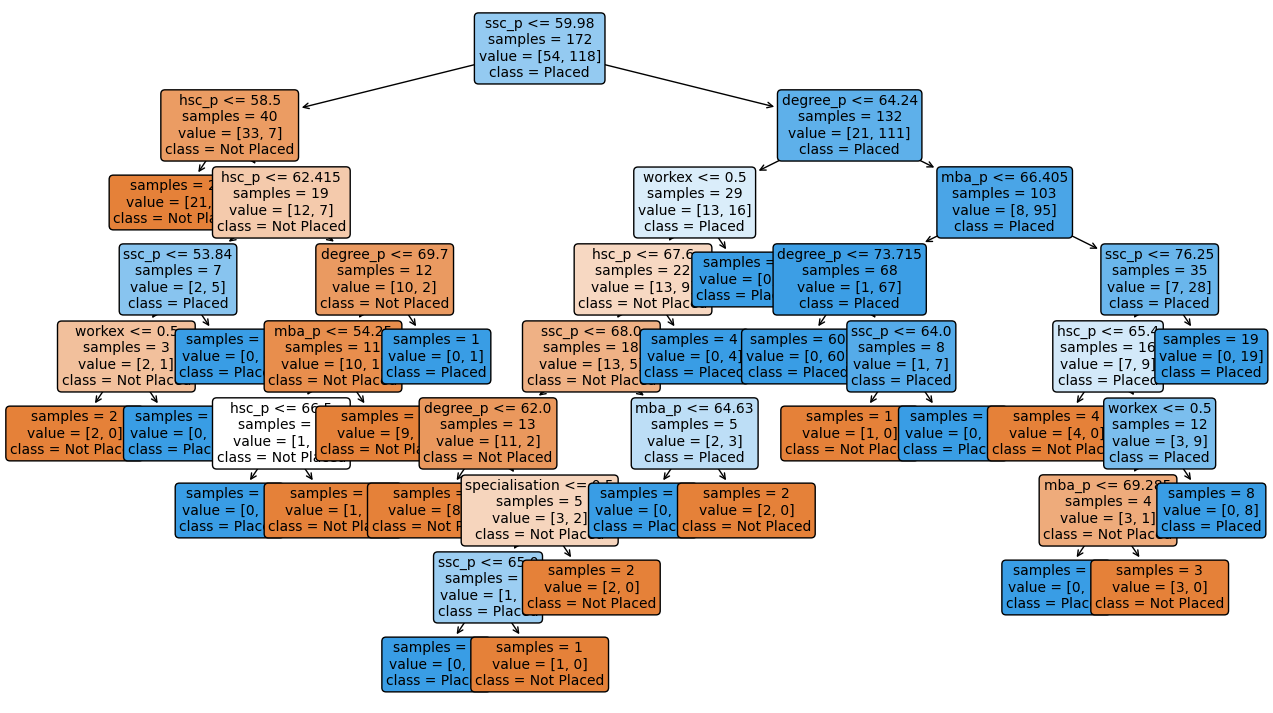

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree   # ← import plot_tree

# ---- Features --------------------------------------------------
cols = ['gender', 'specialisation', 'degree_t', 'workex',
        'ssc_p', 'hsc_p', 'degree_p', 'mba_p']
X = df[cols].copy()

# Encode categoricals (avoid SettingWithCopyWarning)
cat_cols = ['gender', 'specialisation', 'degree_t', 'workex']
for c in cat_cols:
    X.loc[:, c] = LabelEncoder().fit_transform(X[c])

# ---- Target ----------------------------------------------------
y = LabelEncoder().fit_transform(df['status'])   # 0 = Not Placed, 1 = Placed

# ---- Train‑test split -------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# ---- Fit Decision Tree -------------------------------------------
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# ---- Plot the tree ---------------------------------------------
plt.figure(figsize=(16, 9))
plot_tree(
    dt,
    filled=True,
    class_names=['Not Placed', 'Placed'],
    feature_names=X.columns,
    impurity=False,
    rounded=True,
    fontsize=10
)
plt.show()


In [59]:
from sklearn.tree import DecisionTreeClassifier

# Assuming the DecisionTree classifier has already been fitted as `dt`
# and the training data are X_train (features) and y_train (target)

costpath = dt.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = costpath.ccp_alphas, costpath.impurities


In [61]:
modellist = []
for alpha in ccp_alphas:          # <-- use the correct variable name
    clf = DecisionTreeClassifier(ccp_alpha=alpha, random_state=42)
    clf.fit(X_train, y_train)
    modellist.append(clf)


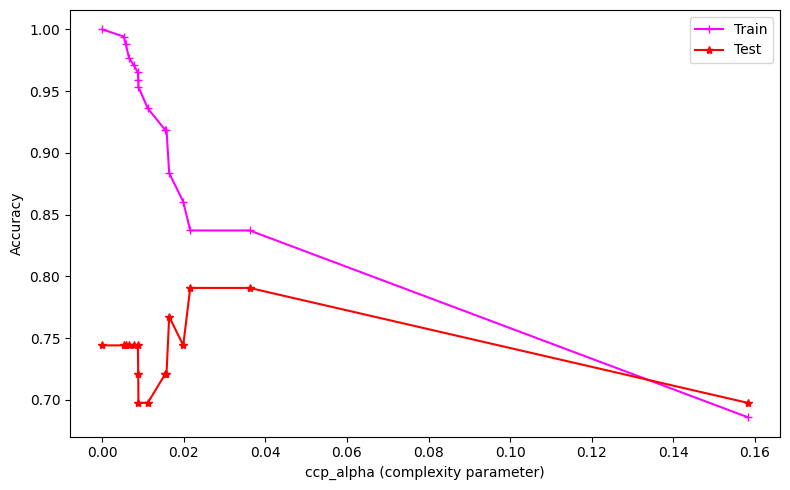

In [63]:
modellist = []
for alpha in ccp_alphas:                     # <-- correct variable name
    clf = DecisionTreeClassifier(ccp_alpha=alpha, random_state=42)
    clf.fit(X_train, y_train)
    modellist.append(clf)
# ---- 3️⃣  Compute train / test accuracies -------------
train_score = [clf.score(X_train, y_train) for clf in modellist]
test_score  = [clf.score(X_test,  y_test)  for clf in modellist]
# ---- 4️⃣  Plot the accuracy vs. α --------------------
plt.figure(figsize=(8, 5))
plt.xlabel('ccp_alpha (complexity parameter)')
plt.ylabel('Accuracy')
plt.plot(ccp_alphas, train_score, label='Train', marker='+', color='magenta')
plt.plot(ccp_alphas, test_score,  label='Test',  marker='*', color='red')
plt.legend()
plt.tight_layout()
plt.show()


[Text(0.5, 0.9, 'SSC_p <= 59.98\ngini = 0.431\nsamples = 172\nvalue = [54, 118]\nclass = Placed'),
 Text(0.3333333333333333, 0.7, 'gini = 0.289\nsamples = 40\nvalue = [33, 7]\nclass = Not_placed'),
 Text(0.6666666666666666, 0.7, 'Degree_p <= 64.24\ngini = 0.268\nsamples = 132\nvalue = [21, 111]\nclass = Placed'),
 Text(0.5, 0.5, 'Work Experience <= 0.5\ngini = 0.495\nsamples = 29\nvalue = [13, 16]\nclass = Placed'),
 Text(0.3333333333333333, 0.3, 'High School_p <= 67.6\ngini = 0.483\nsamples = 22\nvalue = [13, 9]\nclass = Not_placed'),
 Text(0.16666666666666666, 0.1, 'gini = 0.401\nsamples = 18\nvalue = [13, 5]\nclass = Not_placed'),
 Text(0.5, 0.1, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]\nclass = Placed'),
 Text(0.6666666666666666, 0.3, 'gini = 0.0\nsamples = 7\nvalue = [0, 7]\nclass = Placed'),
 Text(0.8333333333333334, 0.5, 'gini = 0.143\nsamples = 103\nvalue = [8, 95]\nclass = Placed')]

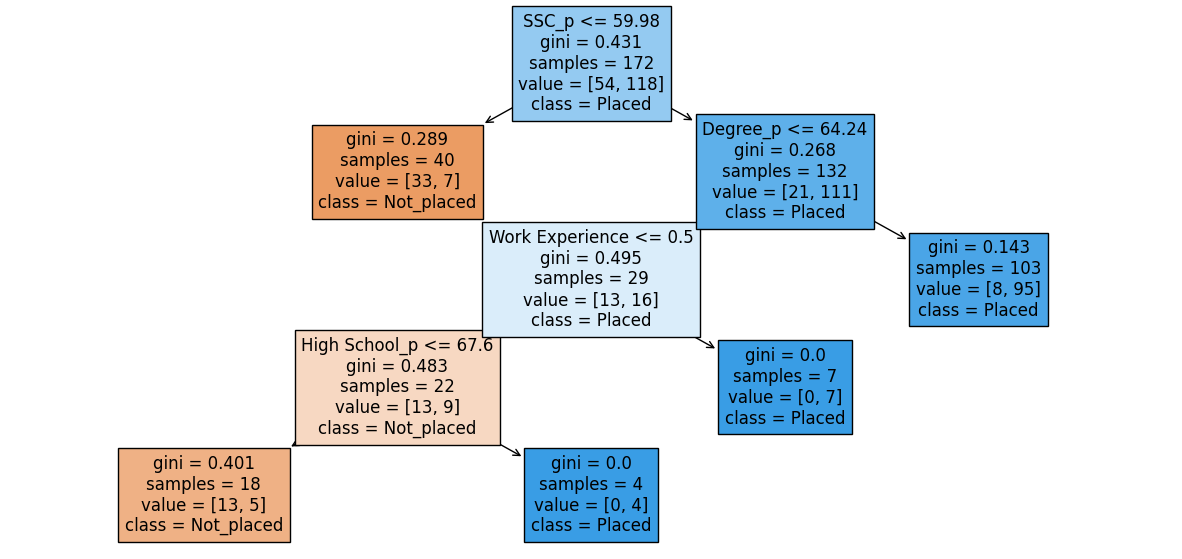

In [64]:
dc = DecisionTreeClassifier(ccp_alpha=0.0195)
dc.fit(X_train,y_train)
plt.figure(figsize=(15,7))
tree.plot_tree(dc,filled=True,class_names=['Not_placed','Placed'],feature_names=train.columns)

# Hyperparameter Tuning

In [66]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

params = {
    'RandomForest': {
        'model': RandomForestClassifier(),
        'params': {
            'n_estimators': [int(x) for x in np.linspace(1, 1200, 10)],
            'max_depth': [int(x) for x in np.linspace(1, 30, 5)],
            'min_samples_split': [2, 5, 10, 12],
            'min_samples_leaf': [2, 5, 10, 12],
            'max_features': ['auto', 'sqrt'],
            'ccp_alpha': [0.0185, 0.0190, 0.0195, 0.0200],
        },
    },
    'logistic': {
        'model': LogisticRegression(),
        'params': {
            'penalty': ['l1', 'l2', 'elasticnet'],
            'C': [0.25, 0.5, 0.75, 1.0],
            'tol': [1e-10, 1e-5, 1e-4, 1e-3, 0.025, 0.25, 0.5],
            'solver': ['lbfgs', 'liblinear', 'saga', 'newton-cg'],
            'multi_class': ['auto', 'ovr', 'multinomial'],
            'max_iter': [int(x) for x in np.linspace(1, 250, 10)],
        },
    },
    'D-tree': {
        'model': DecisionTreeClassifier(),
        'params': {
            'criterion': ['gini', 'entropy'],
            'splitter': ['best', 'random'],
            'min_samples_split': [1, 2, 5, 10, 12],
            'min_samples_leaf': [1, 2, 5, 10, 12],
            'max_features': ['auto', 'sqrt'],
            'ccp_alpha': [0.0185, 0.0190, 0.0195, 0.0200],
        },
    },
    'SVM': {
        'model': SVC(),
        'params': {
            'C': [0.25, 0.5, 0.75, 1.0],
            'tol': [1e-10, 1e-5, 1e-4, 0.025, 0.5, 0.75],
            'kernel': ['linear', 'poly', 'sigmoid', 'rbf'],
            'max_iter': [int(x) for x in np.linspace(1, 250, 10)],
        },
    },
}


In [75]:
import pandas as pd, numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv(r'Placement_Data_Full_Class.csv')
df['salary'] = pd.to_numeric(df['salary'], errors='coerce').fillna(0)

X = df[['gender','specialisation','degree_t','workex','ssc_p','hsc_p','degree_p','mba_p']].copy()
y = LabelEncoder().fit_transform(df['status'])
for c in ['gender','specialisation','degree_t','workex']:
    X.loc[:,c] = LabelEncoder().fit_transform(X[c])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

params = {
    'RandomForest':{
        'model':RandomForestClassifier(),
        'params':{'n_estimators':[int(x) for x in np.linspace(1,1200,10)],
                  'max_depth':[int(x) for x in np.linspace(1,30,5)],
                  'min_samples_split':[2,5,10,12],
                  'min_samples_leaf':[2,5,10,12],
                  'max_features':[None,'sqrt','log2'],
                  'ccp_alpha':[0.0185,0.0190,0.0195,0.0200]}
    },
    'logistic':{
        'model':LogisticRegression(),
        'params':{'penalty':['l1','l2','elasticnet'],
                  'solver':['saga'],
                  'l1_ratio':[0.5],
                  'C':[0.25,0.5,0.75,1.0],
                  'tol':[1e-10,1e-5,1e-4,1e-3,0.025,0.25,0.5],
                  'multi_class':['auto','ovr','multinomial'],
                  'max_iter':[int(x) for x in np.linspace(1,250,10)]}
    },
    'D-tree':{
        'model':DecisionTreeClassifier(),
        'params':{'criterion':['gini','entropy'],
                  'splitter':['best','random'],
                  'min_samples_split':[2,5,10,12],
                  'min_samples_leaf':[1,2,5,10,12],
                  'max_features':[None,'sqrt','log2'],
                  'ccp_alpha':[0.0185,0.0190,0.0195,0.0200]}
    },
    'SVM':{
        'model':SVC(),
        'params':{'C':[0.25,0.5,0.75,1.0],
                  'tol':[1e-10,1e-5,1e-4,0.025,0.5,0.75],
                  'kernel':['linear','poly','sigmoid','rbf'],
                  'max_iter':[int(x) for x in np.linspace(1,250,10)]}
    }
}

scores = []
for name, mp in params.items():
    rs = RandomizedSearchCV(mp['model'], mp['params'], n_iter=10, cv=5,
                            scoring='accuracy', n_jobs=-1, random_state=42,
                            error_score='raise')
    try:
        rs.fit(X_train, y_train)
        scores.append((name, rs.best_score_))
    except Exception as e:
        print(f'❌ {name} failed → {e}')

for n, s in scores:
    print(f'{n}: best CV accuracy = {s:.4f}')


RandomForest: best CV accuracy = 0.8487
logistic: best CV accuracy = 0.8313
D-tree: best CV accuracy = 0.8257
SVM: best CV accuracy = 0.8543


In [78]:
# build a DataFrame from the (model, score) tuples collected above
scores_df = pd.DataFrame(scores, columns=['model_name', 'best_score'])
scores_df


,model_name,best_score
0,RandomForest,0.848739
1,logistic,0.831261
2,D-tree,0.825714
3,SVM,0.854286


In [79]:
scores

[('RandomForest', 0.8487394957983193),
 ('logistic', 0.8312605042016805),
 ('D-tree', 0.8257142857142858),
 ('SVM', 0.8542857142857143)]

In [80]:
# random forest model


rf = RandomForestClassifier(ccp_alpha=0.02, max_depth=30, max_features='sqrt',
                         min_samples_leaf=2, min_samples_split=12,
                         n_estimators=267)
rf.fit(X_train,y_train)
y_pred = rf.predict(X_test)
print(metrics.accuracy_score(y_test,y_pred))

0.813953488372093


In [81]:
# logistic regression

lr = LogisticRegression(C=0.25, max_iter=111, multi_class='ovr', solver='newton-cg',
                     tol=1e-05)

lr.fit(X_train,y_train)
y_pred = lr.predict(X_test)
print(metrics.accuracy_score(y_test,y_pred))


0.8372093023255814


In [83]:
from sklearn import metrics
from sklearn.tree import DecisionTreeClassifier

dc = DecisionTreeClassifier(ccp_alpha=0.019, criterion='entropy',
                             max_features='sqrt',   # ← valid value
                             min_samples_leaf=5,
                             min_samples_split=5,
                             splitter='random')
dc.fit(X_train, y_train)
y_pred = dc.predict(X_test)
print(metrics.accuracy_score(y_test, y_pred))


0.7209302325581395


In [94]:
print(metrics.classification_report(y_test,rf.predict(X_test)))

              precision    recall  f1-score   support

           0       0.94      0.88      0.91        17
           1       0.93      0.96      0.94        26

    accuracy                           0.93        43
   macro avg       0.93      0.92      0.93        43
weighted avg       0.93      0.93      0.93        43



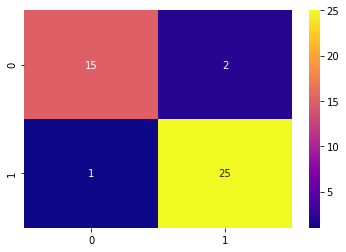

In [95]:
cn = metrics.confusion_matrix(y_test,rf.predict(X_test))
sn.heatmap(cn,annot=True,cmap='plasma')

# Model Testing

In [85]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# encode categorical columns (same encoding used for training)
enc = LabelEncoder()
X_enc = X.copy()
for c in ['gender','specialisation','degree_t','workex']:
    X_enc[c] = enc.fit_transform(X_enc[c])

rf = RandomForestClassifier(random_state=42)
rf.fit(X_enc, y)

predicted = rf.predict(X_enc)
predicted


array([1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0,
       1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1,
       0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0])

In [87]:
# X_enc contains the encoded feature columns used for training
resultdf = X_enc.copy()
resultdf['Actual']    = y               # true labels
resultdf['Predicted'] = predicted        # model predictions
resultdf.head()


,gender,specialisation,degree_t,workex,ssc_p,hsc_p,degree_p,mba_p,Actual,Predicted
0,1,1,2,0,67.00,91.00,58.00,58.80,1,1
1,1,0,2,1,79.33,78.33,77.48,66.28,1,1
2,1,0,0,0,65.00,68.00,64.00,57.80,1,1
3,1,1,2,0,56.00,52.00,52.00,59.43,0,0
4,1,0,0,0,85.80,73.60,73.30,55.50,1,1


In [88]:
resultdf['Actual'].value_counts()

Actual
1    148
0     67
Name: count, dtype: int64

In [89]:
resultdf['Predicted'].value_counts()

Predicted
1    148
0     67
Name: count, dtype: int64

In [90]:
getmappings

{'gender': {'F': 0, 'M': 1},
 'ssc_b': {'Central': 0, 'Others': 1},
 'hsc_b': {'Central': 0, 'Others': 1},
 'hsc_s': {'Arts': 0, 'Commerce': 1, 'Science': 2},
 'degree_t': {'Comm&Mgmt': 0, 'Others': 1, 'Sci&Tech': 2},
 'workex': {'No': 0, 'Yes': 1},
 'specialisation': {'Mkt&Fin': 0, 'Mkt&HR': 1},
 'status': {'Not Placed': 0, 'Placed': 1}}

### Predicted Probability

In [92]:
# encode the original training data the same way it was encoded for fitting
X_enc = X.copy()
for c in ['gender', 'specialisation', 'degree_t', 'workex']:
    X_enc[c] = LabelEncoder().fit_transform(X_enc[c])

# probability predictions for all rows at once
proba = rf.predict_proba(X_enc)

proba[:5]      # show first 5 rows


array([[0.2 , 0.8 ],
       [0.  , 1.  ],
       [0.05, 0.95],
       [0.98, 0.02],
       [0.  , 1.  ]])

In [105]:
predicted[0][0],predicted[0][0][0],predicted[0][0][1]

(array([0.29574242, 0.70425758]), 0.2957424200985559, 0.7042575799014439)

In [94]:

rf = RandomForestClassifier(random_state=42).fit(X_enc, y)

proba = rf.predict_proba(X_enc)

resultdf["Prob_not_getting_placed"] = proba[:, 0]
resultdf["Prob_getting_placed"]    = proba[:, 1]
resultdf


,gender,specialisation,degree_t,workex,ssc_p,hsc_p,degree_p,mba_p,Actual,Predicted,Prob_not_getting_placed,Prob_getting_placed
0,1,1,2,0,67.00,91.00,58.00,58.80,1,1,0.20,0.80
1,1,0,2,1,79.33,78.33,77.48,66.28,1,1,0.00,1.00
2,1,0,0,0,65.00,68.00,64.00,57.80,1,1,0.05,0.95
3,1,1,2,0,56.00,52.00,52.00,59.43,0,0,0.98,0.02
4,1,0,0,0,85.80,73.60,73.30,55.50,1,1,0.00,1.00
...,...,...,...,...,...,...,...,...,...,...,...,...
210,1,0,0,0,80.60,82.00,77.60,74.49,1,1,0.04,0.96
211,1,0,2,0,58.00,60.00,72.00,53.62,1,1,0.09,0.91
212,1,0,0,1,67.00,67.00,73.00,69.72,1,1,0.04,0.96
213,0,1,0,0,74.00,66.00,58.00,60.23,1,1,0.19,0.81


In [95]:
# saving the model

import pickle
file = open('campusplacementpredictor.pkl','wb')
pickle.dump(rf,file)
file.close()

### Conclusions


 + 16 records were missclassified,resulting in the accuracy of 93% on testing data
 + Random Forest model gave the best results
 